<a href="https://colab.research.google.com/github/nileve-teo/Metodos-numericos/blob/main/Interpolando%20puntos%20de%20la%20mano.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📌 Interpolación de la Mano

## 🔗 Enlace GitHub
Coloca aquí tu repositorio:

https://github.com/nileve-teo/Metodos-numericos/blob/cf5e38b4900286a96a5d8c592c7d8343009314a8/Interpolando%20puntos%20de%20la%20mano.ipynb

Incluye:
- Código de Lagrange
- Código de Newton
- Código matricial
- Código de splines cúbicos
- Imágenes de ejecución

Mano:


In [27]:
import numpy as np
import pandas as pd
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# -----------------------------
# DATOS
# -----------------------------
x = np.array([
-6.31,-6.72,-6.82,-7.2,-6.96,-7.31,-7.09,-6.87,-7.18,-7.46,
-7.3,-6.85,-6.64,-6.86,-6.64,-6.74,-6.88,-6.58,-6.43,-6.44,
-6.39,-6.2,-6.28,-6.05,-6.23,-6.19,-6.02,-5.82,-5.84,-5.84,
-5.61,-5.69,-5.44,-5.56,-5.64,-5.75,-5.93,-5.95,-5.71,-5.81,
-5.9,-5.92,-5.93
])

y = np.array([
2.84,2.95,3.31,3.78,4.16,4.31,4.37,4.4,4.54,4.69,
4.77,4.75,5.15,5.59,5.53,5.67,5.25,4.72,4.61,5.19,
5.66,5.56,5.74,5.18,4.75,4.61,5.56,5.64,5.21,4.8,
5.18,4.94,5.14,4.78,4.51,4.48,4.65,4.47,4.19,3.62,
3.29,3.09,2.91
])

# -----------------------------
# DATAFRAME
# -----------------------------
df = pd.DataFrame({
    "Punto": np.arange(len(x)),
    "X": np.round(x, 2),
    "Y": np.round(y, 2)
})

# -----------------------------
# ORDEN DE MANO
# -----------------------------
ruta = [
    0,
    1, 2, 3, 5, 9, 10, 8, 6, 4, 7, 11,
    16, 13, 15, 14, 12, 17, 18, 19, 20,
    22, 21, 24, 25, 23, 26, 27, 28, 36,
    37, 29, 31, 30, 32, 33, 34, 35, 38,
    39, 40, 41, 42, 0
]

xs = [x[i] for i in ruta]
ys = [y[i] for i in ruta]

# -----------------------------
# FIGURA
# -----------------------------
fig = make_subplots(
    rows=1,
    cols=2,
    column_widths=[0.45, 0.55],
    specs=[[{"type": "table"}, {"type": "scatter"}]]
)

# -----------------------------
# TABLA
# -----------------------------
fig.add_trace(
    go.Table(
        header=dict(
            values=["Punto", "X", "Y"],
            fill_color="#A8D8FF",
            font=dict(color="black", size=14),
            line=dict(color="gray", width=1.2)
        ),
        cells=dict(
            values=[df["Punto"], df["X"], df["Y"]],
            fill_color="#EAF8FF",
            font=dict(color="black", size=12),
            line=dict(color="lightgray", width=1)
        )
    ),
    row=1, col=1
)

# -----------------------------
# MANO RELLENA
# -----------------------------
fig.add_trace(
    go.Scatter(
        x=xs,
        y=ys,
        mode="lines",
        fill="toself",
        fillcolor="rgba(173,216,230,0.6)",  # celeste bebé
        line=dict(color="blue", width=2),
        hoverinfo="skip",
        showlegend=False
    ),
    row=1, col=2
)

# -----------------------------
# PUNTOS
# -----------------------------
fig.add_trace(
    go.Scatter(
        x=x,
        y=y,
        mode="markers+text",
        text=df["Punto"],
        textposition="top center",
        marker=dict(size=8, color="red"),
        hovertemplate=
        "<b>Punto %{text}</b><br>" +
        "X = %{x}<br>" +
        "Y = %{y}<extra></extra>"
    ),
    row=1, col=2
)

# -----------------------------
# EJE Y PROPORCION
# -----------------------------
fig.update_yaxes(scaleanchor="x", scaleratio=1, row=1, col=2)

# -----------------------------
# ESTILO GRÁFICA
# -----------------------------
fig.update_xaxes(
    showgrid=True,
    gridcolor="lightgray",
    showline=True,
    linecolor="gray",
    mirror=True,
    row=1, col=2
)

fig.update_yaxes(
    showgrid=True,
    gridcolor="lightgray",
    showline=True,
    linecolor="gray",
    mirror=True,
    row=1, col=2
)

# -----------------------------
# DISEÑO GENERAL
# -----------------------------
fig.update_layout(
    title=dict(
        text="Tabla de puntos y gráfica",
        font=dict(family="Verdana", size=25, color="black"),
        x=0.5
    ),
    width=1300,
    height=750,

    paper_bgcolor="#DFF6FF",  # celeste bebé
    plot_bgcolor="#FFFDD0"    # crema
)

fig.show()


---

#  ¿Por qué Lagrange, Newton y el método matricial no funcionan bien?

---
##  1. Método de Lagrange

El método de Lagrange construye un único polinomio global que pasa por todos los puntos.

### Problemas:
- Cuando hay muchos puntos, el polinomio es de alto grado
- Genera oscilaciones (fenómeno de Runge)
- Se deforma en los extremos
- No representa bien formas complejas

👉 Resultado: la figura de la mano se deforma.



##  2. Método de Newton (diferencias divididas)

Es equivalente a Lagrange pero en forma más eficiente.

### Problemas:
- También genera un polinomio global
- Alta sensibilidad a los datos
- Oscilaciones en zonas con muchos puntos
- No respeta la geometría real

👉 Resultado: dedos o bordes deformados.



## ⚠️ 3. Método matricial (Vandermonde)

Resuelve un sistema para encontrar el polinomio interpolante.

### Problemas:
- Matriz de Vandermonde mal condicionada
- Errores numéricos importantes
- Inestabilidad con muchos puntos
- Alto costo computacional

👉 Resultado: pérdida de precisión en la forma.

---

# ✅ ¿Por qué los splines cúbicos sí funcionan bien?

---

## 🌟 Splines cúbicos

En lugar de un solo polinomio, se usan polinomios por tramos.


## ✔ Ventajas:

### 🔹 1. Evita polinomio global
Cada tramo es independiente → no hay oscilaciones grandes.


### 🔹 2. Suavidad
Garantiza continuidad:
- C0 (posición)
- C1 (pendiente)
- C2 (curvatura)

👉 Resultado: curvas naturales.


### 🔹 3. Estabilidad numérica
No usa sistemas mal condicionados como Vandermonde.



### 🔹 4. Mejor ajuste a la forma
Cada segmento sigue la geometría local.

👉 Resultado: la mano se ve realista.

---

# 🧠 CONCLUSIÓN

- ❌ Lagrange → inestable y con oscilaciones  
- ❌ Newton → mismo problema de polinomio global  
- ❌ Matricial → errores numéricos  
- ✅ Splines cúbicos → método estable y suave  

---

# P. LAGRANGE

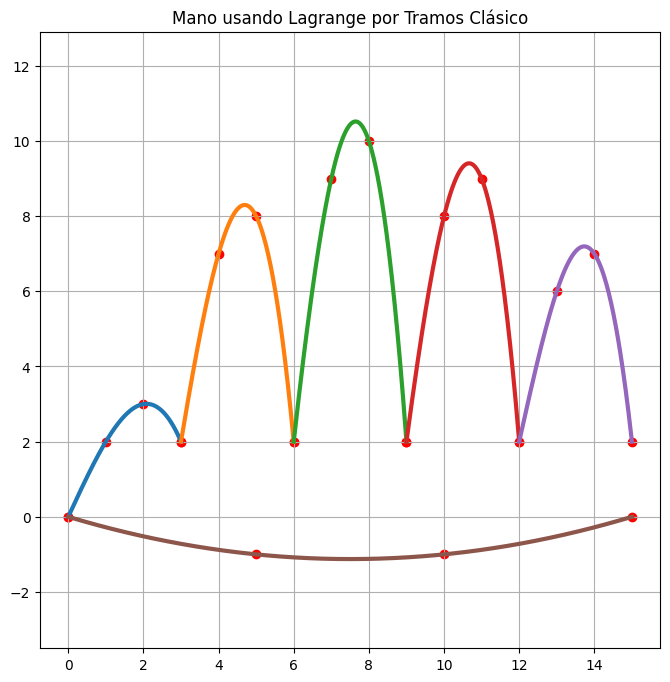

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================
# POLINOMIO DE LAGRANGE
# ==========================

def lagrange(xd, yd, xeval):

    yeval = np.zeros_like(xeval)

    n = len(xd)

    for i in range(n):

        Li = np.ones_like(xeval)

        for j in range(n):

            if i != j:

                Li *= (
                    (xeval - xd[j]) /
                    (xd[i] - xd[j])
                )

        yeval += yd[i] * Li

    return yeval


# ==========================
# TRAMOS DE LA MANO
# ==========================

tramos = [

    # Pulgar
    (
        np.array([0,1,2,3]),
        np.array([0,2,3,2])
    ),

    # Índice
    (
        np.array([3,4,5,6]),
        np.array([2,7,8,2])
    ),

    # Medio
    (
        np.array([6,7,8,9]),
        np.array([2,9,10,2])
    ),

    # Anular
    (
        np.array([9,10,11,12]),
        np.array([2,8,9,2])
    ),

    # Meñique
    (
        np.array([12,13,14,15]),
        np.array([2,6,7,2])
    ),

    # Palma inferior
    (
        np.array([0,5,10,15]),
        np.array([0,-1,-1,0])
    )

]

# ==========================
# GRAFICA
# ==========================

plt.figure(figsize=(8,8))

for xd, yd in tramos:

    xx = np.linspace(
        np.min(xd),
        np.max(xd),
        200
    )

    yy = lagrange(
        xd,
        yd,
        xx
    )

    plt.plot(
        xx,
        yy,
        linewidth=3
    )

    plt.scatter(
        xd,
        yd,
        color='red'
    )

plt.title(
    "Mano usando Lagrange por Tramos Clásico"
)

plt.axis('equal')
plt.grid(True)

plt.show()

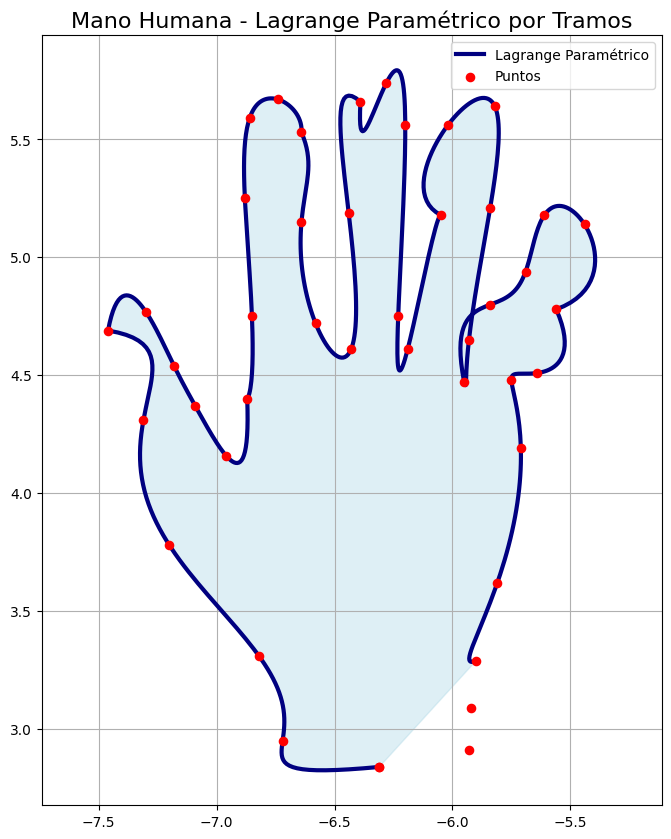

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================
# DATOS DE LA MANO
# =====================================

x = np.array([
-6.31,-6.72,-6.82,-7.2,-6.96,-7.31,-7.09,-6.87,-7.18,-7.46,
-7.3,-6.85,-6.64,-6.86,-6.64,-6.74,-6.88,-6.58,-6.43,-6.44,
-6.39,-6.2,-6.28,-6.05,-6.23,-6.19,-6.02,-5.82,-5.84,-5.84,
-5.61,-5.69,-5.44,-5.56,-5.64,-5.75,-5.93,-5.95,-5.71,-5.81,
-5.9,-5.92,-5.93
])

y = np.array([
2.84,2.95,3.31,3.78,4.16,4.31,4.37,4.4,4.54,4.69,
4.77,4.75,5.15,5.59,5.53,5.67,5.25,4.72,4.61,5.19,
5.66,5.56,5.74,5.18,4.75,4.61,5.56,5.64,5.21,4.8,
5.18,4.94,5.14,4.78,4.51,4.48,4.65,4.47,4.19,3.62,
3.29,3.09,2.91
])

# =====================================
# RUTA DEL CONTORNO
# =====================================

ruta = [
0,
1,2,3,5,9,10,8,6,4,7,11,
16,13,15,14,12,17,18,19,20,
22,21,24,25,23,26,27,28,36,
37,29,31,30,32,33,34,35,38,
39,40,41,42,0
]

x = np.array([x[i] for i in ruta])
y = np.array([y[i] for i in ruta])

# =====================================
# LAGRANGE
# =====================================

def lagrange(t_data, f_data, t_eval):

    resultado = np.zeros_like(
        t_eval,
        dtype=float
    )

    n = len(t_data)

    for i in range(n):

        Li = np.ones_like(t_eval)

        for j in range(n):

            if i != j:

                Li *= (
                    (t_eval - t_data[j]) /
                    (t_data[i] - t_data[j])
                )

        resultado += f_data[i] * Li

    return resultado

# =====================================
# PARAMÉTRICO POR TRAMOS
# =====================================

tam_tramo = 6

X_total = []
Y_total = []

for i in range(0, len(x)-tam_tramo+1, tam_tramo-1):

    x_sub = x[i:i+tam_tramo]
    y_sub = y[i:i+tam_tramo]

    t = np.linspace(
        0,
        1,
        len(x_sub)
    )

    t_eval = np.linspace(
        0,
        1,
        100
    )

    x_interp = lagrange(
        t,
        x_sub,
        t_eval
    )

    y_interp = lagrange(
        t,
        y_sub,
        t_eval
    )

    X_total.extend(x_interp)
    Y_total.extend(y_interp)

# =====================================
# GRÁFICA
# =====================================

plt.figure(figsize=(8,10))

plt.plot(
    X_total,
    Y_total,
    color='navy',
    linewidth=3,
    label='Lagrange Paramétrico'
)

plt.fill(
    X_total,
    Y_total,
    color='lightblue',
    alpha=0.4
)

plt.scatter(
    x,
    y,
    color='red',
    s=35,
    zorder=5,
    label='Puntos'
)

plt.title(
    "Mano Humana - Lagrange Paramétrico por Tramos",
    fontsize=16
)

plt.axis('equal')
plt.grid(True)
plt.legend()

plt.show()

# P NEWTON

# P. NEWTON

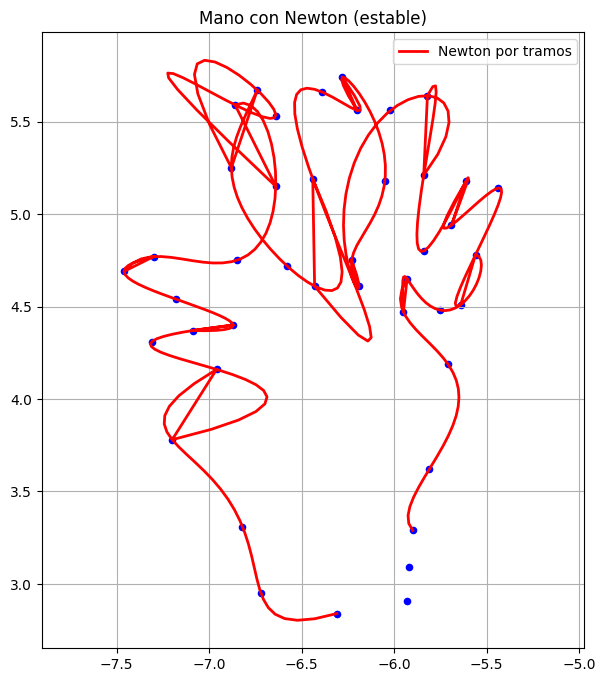

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# DATOS
# -----------------------------
x = np.array([
-6.31,-6.72,-6.82,-7.2,-6.96,-7.31,-7.09,-6.87,-7.18,-7.46,
-7.3,-6.85,-6.64,-6.86,-6.64,-6.74,-6.88,-6.58,-6.43,-6.44,
-6.39,-6.2,-6.28,-6.05,-6.23,-6.19,-6.02,-5.82,-5.84,-5.84,
-5.61,-5.69,-5.44,-5.56,-5.64,-5.75,-5.93,-5.95,-5.71,-5.81,
-5.9,-5.92,-5.93
])

y = np.array([
2.84,2.95,3.31,3.78,4.16,4.31,4.37,4.4,4.54,4.69,
4.77,4.75,5.15,5.59,5.53,5.67,5.25,4.72,4.61,5.19,
5.66,5.56,5.74,5.18,4.75,4.61,5.56,5.64,5.21,4.8,
5.18,4.94,5.14,4.78,4.51,4.48,4.65,4.47,4.19,3.62,
3.29,3.09,2.91
])

# -----------------------------
# PARAMETRIZACIÓN POR DISTANCIA (MUCHO MEJOR)
# -----------------------------
dx = np.diff(x)
dy = np.diff(y)
dist = np.sqrt(dx**2 + dy**2)
t = np.insert(np.cumsum(dist), 0, 0)
t = t / t[-1]

# -----------------------------
# NEWTON
# -----------------------------
def coef_newton(t, f):
    coef = np.copy(f).astype(float)
    n = len(t)

    for j in range(1, n):
        coef[j:n] = (coef[j:n] - coef[j-1:n-1]) / (t[j:n] - t[0:n-j])

    return coef

def eval_newton(t_data, coef, t_eval):
    n = len(coef)
    y = np.zeros_like(t_eval, dtype=float)

    for i in range(len(t_eval)):
        val = coef[n-1]
        for k in range(n-2, -1, -1):
            val = val * (t_eval[i] - t_data[k]) + coef[k]
        y[i] = val

    return y

# -----------------------------
# TRAMOS MÁS PEQUEÑOS (CLAVE)
# -----------------------------
def newton_tramos(x, y, tam=5):
    X, Y = [], []

    dx = np.diff(x)
    dy = np.diff(y)
    dist = np.sqrt(dx**2 + dy**2)
    t = np.insert(np.cumsum(dist), 0, 0)
    t = t / t[-1]

    for i in range(0, len(x) - tam, tam - 2):

        x_sub = x[i:i+tam]
        y_sub = y[i:i+tam]
        t_sub = t[i:i+tam]

        t_eval = np.linspace(t_sub[0], t_sub[-1], 30)

        cx = coef_newton(t_sub, x_sub)
        cy = coef_newton(t_sub, y_sub)

        X.extend(eval_newton(t_sub, cx, t_eval))
        Y.extend(eval_newton(t_sub, cy, t_eval))

    return np.array(X), np.array(Y)

# -----------------------------
# CURVA
# -----------------------------
x_new, y_new = newton_tramos(x, y, tam=5)

# -----------------------------
# GRAFICO
# -----------------------------
plt.figure(figsize=(7,8))

plt.plot(x_new, y_new, 'r', linewidth=2, label='Newton por tramos')
plt.scatter(x, y, color='blue', s=20)

plt.title("Mano con Newton (estable)")
plt.axis("equal")
plt.grid(True)
plt.legend()

plt.show()

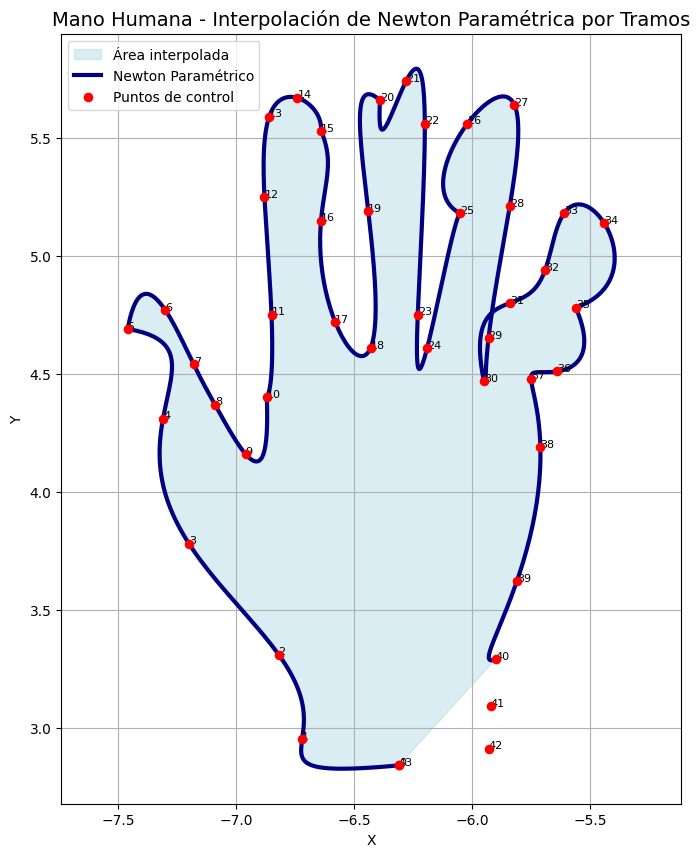

In [40]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================
# DATOS
# =====================================

x = np.array([
-6.31,-6.72,-6.82,-7.2,-6.96,-7.31,-7.09,-6.87,-7.18,-7.46,
-7.3,-6.85,-6.64,-6.86,-6.64,-6.74,-6.88,-6.58,-6.43,-6.44,
-6.39,-6.2,-6.28,-6.05,-6.23,-6.19,-6.02,-5.82,-5.84,-5.84,
-5.61,-5.69,-5.44,-5.56,-5.64,-5.75,-5.93,-5.95,-5.71,-5.81,
-5.9,-5.92,-5.93
])

y = np.array([
2.84,2.95,3.31,3.78,4.16,4.31,4.37,4.4,4.54,4.69,
4.77,4.75,5.15,5.59,5.53,5.67,5.25,4.72,4.61,5.19,
5.66,5.56,5.74,5.18,4.75,4.61,5.56,5.64,5.21,4.8,
5.18,4.94,5.14,4.78,4.51,4.48,4.65,4.47,4.19,3.62,
3.29,3.09,2.91
])

# =====================================
# RUTA DEL CONTORNO
# =====================================

ruta = [
0,
1,2,3,5,9,10,8,6,4,7,11,
16,13,15,14,12,17,18,19,20,
22,21,24,25,23,26,27,28,36,
37,29,31,30,32,33,34,35,38,
39,40,41,42,0
]

x = np.array([x[i] for i in ruta])
y = np.array([y[i] for i in ruta])

# =====================================
# DIFERENCIAS DIVIDIDAS DE NEWTON
# =====================================

def coef_newton(t, f):

    n = len(t)

    coef = np.copy(f).astype(float)

    for j in range(1, n):
        coef[j:n] = (
            coef[j:n] - coef[j-1:n-1]
        ) / (
            t[j:n] - t[0:n-j]
        )

    return coef

# =====================================
# EVALUAR POLINOMIO
# =====================================

def eval_newton(t, coef, tp):

    p = coef[-1]

    for k in range(len(coef)-2, -1, -1):
        p = coef[k] + (tp - t[k]) * p

    return p

# =====================================
# NEWTON PARAMÉTRICO POR TRAMOS
# =====================================

tam_tramo = 6

X_total = []
Y_total = []

for i in range(0, len(x)-tam_tramo+1, tam_tramo-1):

    x_sub = x[i:i+tam_tramo]
    y_sub = y[i:i+tam_tramo]

    t = np.linspace(
        0,
        1,
        len(x_sub)
    )

    coef_x = coef_newton(t, x_sub)
    coef_y = coef_newton(t, y_sub)

    t_eval = np.linspace(
        0,
        1,
        120
    )

    x_interp = np.array([
        eval_newton(t, coef_x, ti)
        for ti in t_eval
    ])

    y_interp = np.array([
        eval_newton(t, coef_y, ti)
        for ti in t_eval
    ])

    X_total.extend(x_interp)
    Y_total.extend(y_interp)

X_total = np.array(X_total)
Y_total = np.array(Y_total)

# =====================================
# GRÁFICA
# =====================================

plt.figure(figsize=(8,10))

plt.fill(
    X_total,
    Y_total,
    color="lightblue",
    alpha=0.45,
    label="Área interpolada"
)

plt.plot(
    X_total,
    Y_total,
    color="navy",
    linewidth=3,
    label="Newton Paramétrico"
)

plt.scatter(
    x,
    y,
    color="red",
    s=35,
    zorder=5,
    label="Puntos de control"
)

for i in range(len(x)):
    plt.text(
        x[i],
        y[i],
        str(i),
        fontsize=8
    )

plt.title(
    "Mano Humana - Interpolación de Newton Paramétrica por Tramos",
    fontsize=14
)

plt.xlabel("X")
plt.ylabel("Y")

plt.axis('equal')
plt.grid(True)
plt.legend()

plt.show()

# P. MATRICIAL

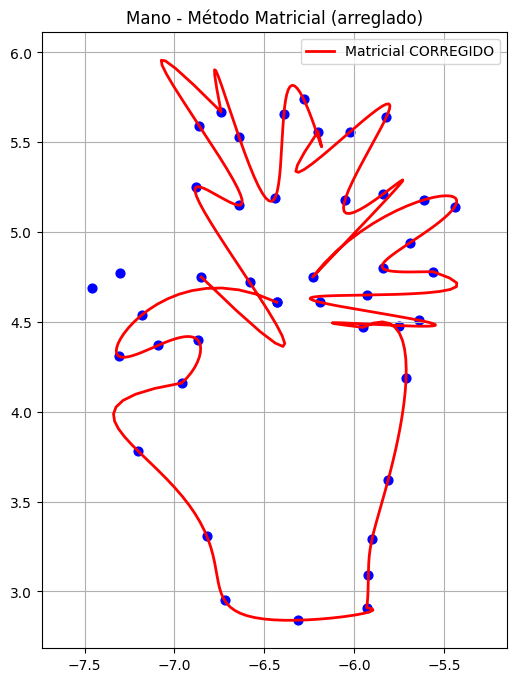

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# DATOS
# -----------------------------
x = np.array([
-6.31,-6.72,-6.82,-7.2,-6.96,-7.31,-7.09,-6.87,-7.18,-7.46,
-7.3,-6.85,-6.64,-6.86,-6.64,-6.74,-6.88,-6.58,-6.43,-6.44,
-6.39,-6.2,-6.28,-6.05,-6.23,-6.19,-6.02,-5.82,-5.84,-5.84,
-5.61,-5.69,-5.44,-5.56,-5.64,-5.75,-5.93,-5.95,-5.71,-5.81,
-5.9,-5.92,-5.93
])

y = np.array([
2.84,2.95,3.31,3.78,4.16,4.31,4.37,4.4,4.54,4.69,
4.77,4.75,5.15,5.59,5.53,5.67,5.25,4.72,4.61,5.19,
5.66,5.56,5.74,5.18,4.75,4.61,5.56,5.64,5.21,4.8,
5.18,4.94,5.14,4.78,4.51,4.48,4.65,4.47,4.19,3.62,
3.29,3.09,2.91
])

# -----------------------------
# ORDENAR
# -----------------------------
cx, cy = np.mean(x), np.mean(y)
ang = np.arctan2(y - cy, x - cx)
idx = np.argsort(ang)

x = x[idx]
y = y[idx]

# cerrar figura
x = np.append(x, x[0])
y = np.append(y, y[0])

# -----------------------------
# VANDERMONDE CORRECTA
# -----------------------------
def vandermonde(t, grado):
    return np.vander(t, N=grado, increasing=True)

# -----------------------------
# METODO MATRICIAL POR TRAMOS
# -----------------------------
def matricial_tramos(x, y, tam=6):
    X_total, Y_total = [], []

    n = len(x)

    for i in range(0, n - tam, tam - 1):
        x_sub = x[i:i+tam]
        y_sub = y[i:i+tam]

        t = np.linspace(0, 1, len(x_sub))
        t_eval = np.linspace(0, 1, 50)

        grado = len(t)

        # matriz correcta
        V = vandermonde(t, grado)

        # resolver
        coef_x = np.linalg.solve(V, x_sub)
        coef_y = np.linalg.solve(V, y_sub)

        # evaluar (MISMO grado)
        V_eval = vandermonde(t_eval, grado)

        x_vals = V_eval @ coef_x
        y_vals = V_eval @ coef_y

        X_total.extend(x_vals)
        Y_total.extend(y_vals)

    return np.array(X_total), np.array(Y_total)

# -----------------------------
# GENERAR CURVA
# -----------------------------
x_mat, y_mat = matricial_tramos(x, y, tam=6)

# -----------------------------
# GRAFICA
# -----------------------------
plt.figure(figsize=(6,8))

plt.plot(x_mat, y_mat, 'r', linewidth=2, label='Matricial CORREGIDO')
plt.scatter(x, y, color='blue', s=40)

plt.title("Mano - Método Matricial (arreglado)")
plt.axis('equal')
plt.grid()
plt.legend()

plt.show()

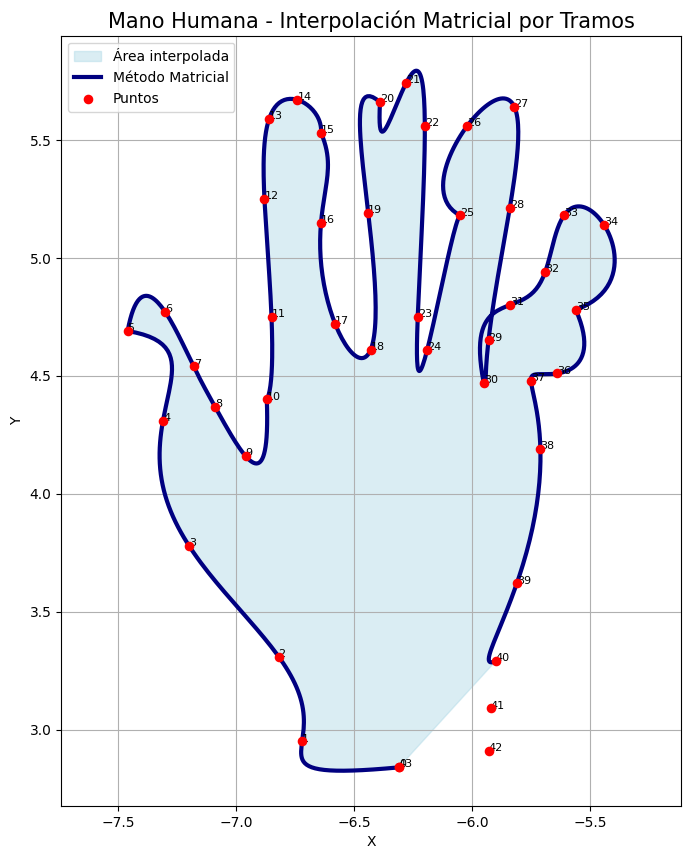

In [41]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# DATOS
# =====================================================

x = np.array([
-6.31,-6.72,-6.82,-7.2,-6.96,-7.31,-7.09,-6.87,-7.18,-7.46,
-7.3,-6.85,-6.64,-6.86,-6.64,-6.74,-6.88,-6.58,-6.43,-6.44,
-6.39,-6.2,-6.28,-6.05,-6.23,-6.19,-6.02,-5.82,-5.84,-5.84,
-5.61,-5.69,-5.44,-5.56,-5.64,-5.75,-5.93,-5.95,-5.71,-5.81,
-5.9,-5.92,-5.93
])

y = np.array([
2.84,2.95,3.31,3.78,4.16,4.31,4.37,4.4,4.54,4.69,
4.77,4.75,5.15,5.59,5.53,5.67,5.25,4.72,4.61,5.19,
5.66,5.56,5.74,5.18,4.75,4.61,5.56,5.64,5.21,4.8,
5.18,4.94,5.14,4.78,4.51,4.48,4.65,4.47,4.19,3.62,
3.29,3.09,2.91
])

# =====================================================
# RUTA DEL CONTORNO
# =====================================================

ruta = [
0,
1,2,3,5,9,10,8,6,4,7,11,
16,13,15,14,12,17,18,19,20,
22,21,24,25,23,26,27,28,36,
37,29,31,30,32,33,34,35,38,
39,40,41,42,0
]

x = np.array([x[i] for i in ruta])
y = np.array([y[i] for i in ruta])

# =====================================================
# MATRIZ DE VANDERMONDE
# =====================================================

def vandermonde(t):

    n = len(t)

    V = np.zeros((n,n))

    for i in range(n):
        for j in range(n):
            V[i,j] = t[i]**j

    return V

# =====================================================
# MÉTODO MATRICIAL POR TRAMOS
# =====================================================

def matricial_por_tramos(x, y, tam_tramo=6):

    X_total = []
    Y_total = []

    for k in range(
        0,
        len(x)-tam_tramo+1,
        tam_tramo-1
    ):

        x_sub = x[k:k+tam_tramo]
        y_sub = y[k:k+tam_tramo]

        t = np.linspace(
            0,
            1,
            len(x_sub)
        )

        V = vandermonde(t)

        coef_x = np.linalg.solve(
            V,
            x_sub
        )

        coef_y = np.linalg.solve(
            V,
            y_sub
        )

        t_eval = np.linspace(
            0,
            1,
            120
        )

        V_eval = np.vander(
            t_eval,
            N=len(t),
            increasing=True
        )

        x_interp = V_eval @ coef_x
        y_interp = V_eval @ coef_y

        X_total.extend(x_interp)
        Y_total.extend(y_interp)

    return (
        np.array(X_total),
        np.array(Y_total)
    )

# =====================================================
# INTERPOLACIÓN
# =====================================================

Xc, Yc = matricial_por_tramos(
    x,
    y,
    tam_tramo=6
)

# =====================================================
# GRÁFICA
# =====================================================

plt.figure(figsize=(8,10))

plt.fill(
    Xc,
    Yc,
    color="lightblue",
    alpha=0.45,
    label="Área interpolada"
)

plt.plot(
    Xc,
    Yc,
    color="navy",
    linewidth=3,
    label="Método Matricial"
)

plt.scatter(
    x,
    y,
    color="red",
    s=35,
    zorder=5,
    label="Puntos"
)

for i in range(len(x)):
    plt.text(
        x[i],
        y[i],
        str(i),
        fontsize=8
    )

plt.title(
    "Mano Humana - Interpolación Matricial por Tramos",
    fontsize=15
)

plt.xlabel("X")
plt.ylabel("Y")

plt.axis('equal')
plt.grid(True)
plt.legend()

plt.show()

# SPLINE CÚBICO

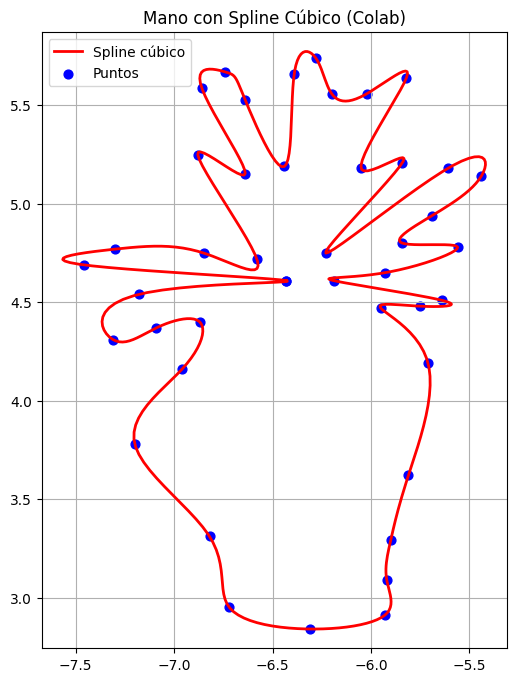

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

# -----------------------------
# TUS DATOS
# -----------------------------
x = np.array([
-6.31,-6.72,-6.82,-7.2,-6.96,-7.31,-7.09,-6.87,-7.18,-7.46,
-7.3,-6.85,-6.64,-6.86,-6.64,-6.74,-6.88,-6.58,-6.43,-6.44,
-6.39,-6.2,-6.28,-6.05,-6.23,-6.19,-6.02,-5.82,-5.84,-5.84,
-5.61,-5.69,-5.44,-5.56,-5.64,-5.75,-5.93,-5.95,-5.71,-5.81,
-5.9,-5.92,-5.93
])

y = np.array([
2.84,2.95,3.31,3.78,4.16,4.31,4.37,4.4,4.54,4.69,
4.77,4.75,5.15,5.59,5.53,5.67,5.25,4.72,4.61,5.19,
5.66,5.56,5.74,5.18,4.75,4.61,5.56,5.64,5.21,4.8,
5.18,4.94,5.14,4.78,4.51,4.48,4.65,4.47,4.19,3.62,
3.29,3.09,2.91
])

# -----------------------------
# ORDENAR PUNTOS
# -----------------------------
cx, cy = np.mean(x), np.mean(y)
ang = np.arctan2(y - cy, x - cx)
orden = np.argsort(ang)

x = x[orden]
y = y[orden]

# cerrar figura
x = np.append(x, x[0])
y = np.append(y, y[0])

# -----------------------------
# PARAMETRO t
# -----------------------------
t = np.linspace(0, 1, len(x))

# -----------------------------
# SPLINE CÚBICO PERIÓDICO
# -----------------------------
cs_x = CubicSpline(t, x, bc_type='periodic')
cs_y = CubicSpline(t, y, bc_type='periodic')

t_suave = np.linspace(0, 1, 500)

x_s = cs_x(t_suave)
y_s = cs_y(t_suave)

# -----------------------------
# GRAFICA
# -----------------------------
plt.figure(figsize=(6,8))

plt.plot(x_s, y_s, 'r', linewidth=2, label='Spline cúbico')
plt.scatter(x, y, color='blue', s=40, label='Puntos')

plt.title("Mano con Spline Cúbico (Colab)")
plt.axis('equal')
plt.grid()
plt.legend()

plt.show()

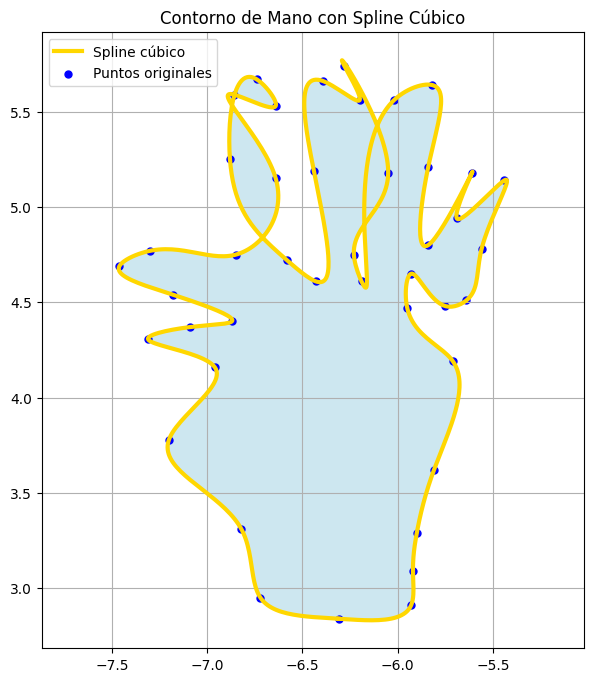

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import splprep, splev

# -----------------------------
# DATOS
# -----------------------------
x = np.array([
-6.31,-6.72,-6.82,-7.2,-6.96,-7.31,-7.09,-6.87,-7.18,-7.46,
-7.3,-6.85,-6.64,-6.86,-6.64,-6.74,-6.88,-6.58,-6.43,-6.44,
-6.39,-6.2,-6.28,-6.05,-6.23,-6.19,-6.02,-5.82,-5.84,-5.84,
-5.61,-5.69,-5.44,-5.56,-5.64,-5.75,-5.93,-5.95,-5.71,-5.81,
-5.9,-5.92,-5.93
])

y = np.array([
2.84,2.95,3.31,3.78,4.16,4.31,4.37,4.4,4.54,4.69,
4.77,4.75,5.15,5.59,5.53,5.67,5.25,4.72,4.61,5.19,
5.66,5.56,5.74,5.18,4.75,4.61,5.56,5.64,5.21,4.8,
5.18,4.94,5.14,4.78,4.51,4.48,4.65,4.47,4.19,3.62,
3.29,3.09,2.91
])

# -----------------------------
# CERRAR CONTORNO
# -----------------------------
x_c = np.append(x, x[0])
y_c = np.append(y, y[0])

# -----------------------------
# SPLINE PARAMÉTRICO
# -----------------------------
tck, u = splprep([x_c, y_c], s=0, per=True)

u_nuevo = np.linspace(0, 1, 1000)

x_suave, y_suave = splev(u_nuevo, tck)

# -----------------------------
# GRAFICAR
# -----------------------------
plt.figure(figsize=(7,8))

plt.fill(x_suave, y_suave,
         color='lightblue',
         alpha=0.6)

plt.plot(x_suave, y_suave,
         color='gold',
         linewidth=3,
         label='Spline cúbico')

plt.scatter(x, y,
            color='blue',
            s=25,
            label='Puntos originales')

plt.title("Contorno de Mano con Spline Cúbico")
plt.axis('equal')
plt.grid(True)
plt.legend()

plt.show()

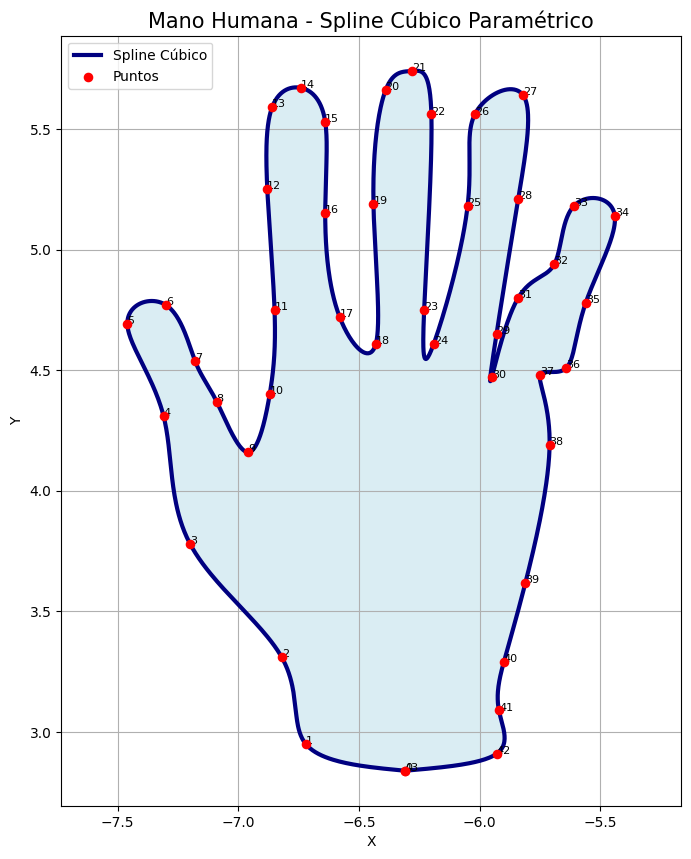

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

# =====================================
# DATOS
# =====================================

x = np.array([
-6.31,-6.72,-6.82,-7.2,-6.96,-7.31,-7.09,-6.87,-7.18,-7.46,
-7.3,-6.85,-6.64,-6.86,-6.64,-6.74,-6.88,-6.58,-6.43,-6.44,
-6.39,-6.2,-6.28,-6.05,-6.23,-6.19,-6.02,-5.82,-5.84,-5.84,
-5.61,-5.69,-5.44,-5.56,-5.64,-5.75,-5.93,-5.95,-5.71,-5.81,
-5.9,-5.92,-5.93
])

y = np.array([
2.84,2.95,3.31,3.78,4.16,4.31,4.37,4.4,4.54,4.69,
4.77,4.75,5.15,5.59,5.53,5.67,5.25,4.72,4.61,5.19,
5.66,5.56,5.74,5.18,4.75,4.61,5.56,5.64,5.21,4.8,
5.18,4.94,5.14,4.78,4.51,4.48,4.65,4.47,4.19,3.62,
3.29,3.09,2.91
])

# =====================================
# RUTA DEL CONTORNO
# =====================================

ruta = [
0,
1,2,3,5,9,10,8,6,4,7,11,
16,13,15,14,12,17,18,19,20,
22,21,24,25,23,26,27,28,36,
37,29,31,30,32,33,34,35,38,
39,40,41,42,0
]

x = np.array([x[i] for i in ruta])
y = np.array([y[i] for i in ruta])

# =====================================
# PARÁMETRO t
# =====================================

t = np.arange(len(x))

# =====================================
# SPLINES CÚBICOS
# =====================================

sx = CubicSpline(
    t,
    x,
    bc_type='natural'
)

sy = CubicSpline(
    t,
    y,
    bc_type='natural'
)

# =====================================
# EVALUACIÓN
# =====================================

t_fino = np.linspace(
    0,
    len(x)-1,
    2000
)

x_spline = sx(t_fino)
y_spline = sy(t_fino)

# =====================================
# GRÁFICA
# =====================================

plt.figure(figsize=(8,10))

plt.fill(
    x_spline,
    y_spline,
    color="lightblue",
    alpha=0.45
)

plt.plot(
    x_spline,
    y_spline,
    color="navy",
    linewidth=3,
    label="Spline Cúbico"
)

plt.scatter(
    x,
    y,
    color="red",
    s=35,
    zorder=5,
    label="Puntos"
)

for i in range(len(x)):
    plt.text(
        x[i],
        y[i],
        str(i),
        fontsize=8
    )

plt.title(
    "Mano Humana - Spline Cúbico Paramétrico",
    fontsize=15
)

plt.xlabel("X")
plt.ylabel("Y")

plt.axis('equal')
plt.grid(True)
plt.legend()

plt.show()

# PREGUNTA
#

Responde a las preguntas por qué el método de Lagrange, Newton y matricial no responden bien.
¿Por qué el método de splines cúbicos lo hace bien?

Los métodos de interpolación de Lagrange, Newton y el método matricial no responden adecuadamente al representar la forma de una mano porque construyen un único polinomio de alto grado que intenta pasar exactamente por todos los puntos. Cuando se trabaja con muchos datos, este tipo de polinomio tiende a volverse inestable y a presentar oscilaciones indeseadas, conocidas como el fenómeno de Runge. Esto provoca que la curva resultante se deforme y no respete la geometría real del contorno. Además, estos métodos no son adecuados para describir figuras complejas o curvas cerradas, como una mano, ya que tratan de ajustar toda la forma con una sola función global.

En cambio, el método de splines cúbicos ofrece mejores resultados porque divide la interpolación en tramos pequeños, utilizando polinomios de bajo grado en cada segmento. Esto permite evitar las oscilaciones y garantiza una transición suave entre los puntos, manteniendo continuidad en la curva y sus derivadas. Gracias a esta aproximación local, los splines se adaptan mucho mejor a formas complejas, logrando una representación más estable, precisa y fiel del contorno de la mano.